In [10]:
import numpy as np
import matplotlib.pyplot as plt

def simular_apd_komunjer(n, alpha, lam, seed):
    """
    Simula una serie i.i.d. de la Asymmetric Power Distribution (Komunjer).
    
    Parámetros:
    n (int): Tamaño de la muestra (longitud de la serie).
    alpha (float): Parámetro de asimetría (0 < alpha < 1). 
                   alpha < 0.5 genera sesgo a la derecha, alpha > 0.5 sesgo a la izquierda.
    lam (float): Parámetro de decaimiento de colas (lambda > 0).
                 lam = 2 se asimila a una normal, lam = 1 a una Laplace.
    loc (float): Parámetro de ubicación/desplazamiento.
    scale (float): Parámetro de escala (> 0).
    
    Retorna:
    numpy.ndarray: Serie de datos simulados.
    """
    if not (0 < alpha < 1):
        raise ValueError("El parámetro alpha debe estar estrictamente entre 0 y 1.")
    if lam <= 0:
        raise ValueError("El parámetro lambda debe ser mayor que 0.")
        
    rng = np.random.default_rng(seed)
    # 1. Calcular la constante delta
    alpha_lam = alpha ** lam
    one_minus_alpha_lam = (1.0 - alpha) ** lam
    delta = (2.0 * alpha_lam * one_minus_alpha_lam) / (alpha_lam + one_minus_alpha_lam)
    
    # 2. Generar W ~ Gamma(1/lambda, 1)
    w = rng.gamma(shape=1.0/lam, scale=1.0, size=n)
    
    # 3. Generar U ~ Uniforme(0,1) para asignar la masa a cada lado
    u = rng.uniform(0, 1, size=n)
    
    # 4. Construir la variable X aplicando la transformación de signos
    x = np.where(
        u <= alpha,
        -alpha * (w / delta) ** (1.0 / lam),
        (1.0 - alpha) * (w / delta) ** (1.0 / lam)
    )
    
    # 5. Aplicar locación y escala final
    serie_iid = (x - x.mean())/x.std()
    
    return serie_iid

# ==========================================
# Ejemplo de uso y verificación visual
# ==========================================

    

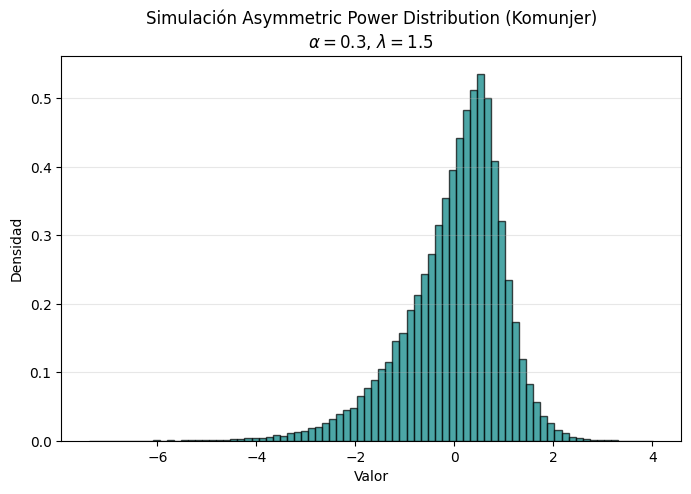

In [11]:

    
# Generamos 10,000 datos: 
# alpha=0.3 (sesgo hacia valores positivos), lambda=1.5 (colas ligeramente más pesadas que normal)
serie = simular_apd_komunjer(n=100000, alpha=0.7, lam=1.35, seed=41)

# Graficamos el histograma para observar la distribución
plt.figure(figsize=(8, 5))
plt.hist(serie, bins=80, density=True, color='teal', alpha=0.7, edgecolor='black')
plt.title('Simulación Asymmetric Power Distribution (Komunjer)\n$\\alpha=0.3$, $\\lambda=1.5$')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [12]:
serie.mean(), serie.std()

(np.float64(-1.9753088054130785e-17), np.float64(1.0))

In [9]:
import numpy as np

def opdyke_statistics(data):
    """
    Calcula el Skewness y la Kurtosis siguiendo el enfoque de 
    consistencia para muestras finitas de Opdyke (2007).
    """
    data = np.array(data)
    n = len(data)
    if n < 4:
        return None, None
    
    # Centralizamos los datos respecto a la media
    mu = np.mean(data)
    diff = data - mu
    
    # Momentos muestrales base
    m2 = np.mean(diff**2)
    m3 = np.mean(diff**3)
    m4 = np.mean(diff**4)
    
    # --- Skewness (Sesgo) ---
    # Ajuste de Opdyke para la consistencia del tercer momento
    skew = (np.sqrt(n * (n - 1)) / (n - 2)) * (m3 / np.power(m2, 1.5))
    
    # --- Kurtosis (Curtosis) ---
    # Opdyke enfatiza el uso del exceso de curtosis con corrección de Bessel
    # y términos de cuarto orden para robustez.
    term1 = (n**2 - 1) / ((n - 2) * (n - 3))
    term2 = (m4 / (m2**2)) - 3 + (6 / (n + 1))
    
    kurtosis = term1 * term2
    
    return skew, kurtosis


s, k = opdyke_statistics(serie)

print(f"Skewness (Opdyke): {s:.4f}")
print(f"Kurtosis (Opdyke): {k:.4f}")

NameError: name 'serie' is not defined

In [13]:
from scipy import stats

stats.kurtosis(serie, fisher=False,),stats.skew(serie)

(np.float64(4.951156667732942), np.float64(-0.9989819556914008))

In [23]:
serie2 = (serie - serie.mean())/serie.std()

In [14]:
aux = (serie+0.7007242485245112)/ 1.2276935614464604
stats.kurtosis(aux, fisher=False), stats.skew(aux)

(np.float64(4.951156667732944), np.float64(-0.9989819556914005))

In [21]:
import numpy as np
from scipy.special import gamma

def calcular_skew_kurtosis_apd(alpha, lam):
    # 1. Calcular constante delta
    num = 2 * (alpha**lam) * ((1 - alpha)**lam)
    den = (alpha**lam) + ((1 - alpha)**lam)
    delta = num / den
    
    # 2. Función para el momento crudo E[X^k]
    def raw_moment(k):
        M_k = (1 - alpha)**(k + 1) + ((-1)**k) * (alpha**(k + 1))
        G_k = gamma((k + 1) / lam) / ((delta**(k / lam)) * gamma(1 / lam))
        return G_k * M_k

    # 3. Extraer los primeros 4 momentos
    m1 = raw_moment(1)
    m2 = raw_moment(2)
    m3 = raw_moment(3)
    m4 = raw_moment(4)
    
    # 4. Calcular momentos centrales
    var = m2 - m1**2
    sd = np.sqrt(var)
    print(m1, sd)
    
    mu3 = m3 - 3*m1*m2 + 2*(m1**3)
    mu4 = m4 - 4*m1*m3 + 6*(m1**2)*m2 - 3*(m1**4)
    
    # 5. Obtener Skewness y Kurtosis
    skew = mu3 / (sd**3)
    kurtosis = mu4 / (sd**4)
    
    return skew, kurtosis

# Ejecutar para los parámetros del usuario
alpha_val = 0.5
lam_val = 0.2
skew_exacto, kurt_exacto = calcular_skew_kurtosis_apd(alpha_val, lam_val)

print(f"Parámetros: alpha={alpha_val}, lambda={lam_val}")
print(f"Skewness Teórico: {skew_exacto:.6f}")
print(f"Kurtosis Teórica: {kurt_exacto:.6f}")

0.0 60269.63414523105
Parámetros: alpha=0.5, lambda=0.2
Skewness Teórico: 0.000000
Kurtosis Teórica: 1959.296703


In [30]:
import numpy as np
from scipy.special import gamma
from scipy.optimize import minimize

def calcular_skew_kurtosis_apd(alpha, lam):
    """Calcula los momentos teóricos de la APD de Komunjer."""
    # Constante delta
    num = 2 * (alpha**lam) * ((1 - alpha)**lam)
    den = (alpha**lam) + ((1 - alpha)**lam)
    delta = num / den
    
    # Función para el momento crudo E[X^k]
    def raw_moment(k):
        M_k = (1 - alpha)**(k + 1) + ((-1)**k) * (alpha**(k + 1))
        G_k = gamma((k + 1) / lam) / ((delta**(k / lam)) * gamma(1 / lam))
        return G_k * M_k

    m1 = raw_moment(1)
    m2 = raw_moment(2)
    m3 = raw_moment(3)
    m4 = raw_moment(4)
    
    var = m2 - m1**2
    sd = np.sqrt(var)
    
    mu3 = m3 - 3*m1*m2 + 2*(m1**3)
    mu4 = m4 - 4*m1*m3 + 6*(m1**2)*m2 - 3*(m1**4)
    
    skew = mu3 / (sd**3)
    kurtosis = mu4 / (sd**4)
    
    return skew, kurtosis

def funcion_objetivo(params, target_skew, target_kurt):
    """
    Función de pérdida a minimizar. 
    Usamos la suma de los errores relativos al cuadrado para que 
    la Kurtosis (que es numéricamente mayor) no domine la optimización.
    """
    alpha, lam = params
    
    try:
        skew_calc, kurt_calc = calcular_skew_kurtosis_apd(alpha, lam)
        
        # Error cuadrático relativo
        error_skew = ((skew_calc - target_skew)/target_skew) ** 2
        error_kurt = ((kurt_calc - target_kurt)/target_kurt) ** 2
        
        return error_skew + error_kurt
        
    except Exception:
        # Penalización altísima si los parámetros causan error matemático (overflow de Gamma)
        return 1e10

# ==========================================
# Configuración y Ejecución de la Optimización
# ==========================================

# 1. Definir los objetivos de Opdyke
OBJETIVO_SKEW = 5
OBJETIVO_KURT = 10

# 2. Valores iniciales (Initial Guess) - partimos de lo que reportaba el paper
x0 = [0.7, 1.35]

# 3. Límites (Bounds) para el optimizador:
# alpha: estrictamente entre (0, 1), usamos [0.01, 0.99] para evitar divisiones por cero.
# lambda: estrictamente > 0, usamos [0.5, 5.0] para evitar overflows en la función Gamma.
limites = [(0.01, 0.99), (0.2, 5.0)]

# 4. Ejecutar la optimización (Usamos L-BFGS-B porque soporta límites)
resultado = minimize(
    funcion_objetivo, 
    x0, 
    args=(OBJETIVO_SKEW, OBJETIVO_KURT),
    method='L-BFGS-B',
    bounds=limites
)

# 5. Mostrar Resultados
if resultado.success:
    alpha_opt, lam_opt = resultado.x
    skew_final, kurt_final = calcular_skew_kurtosis_apd(alpha_opt, lam_opt)
    
    print("=== RESULTADOS DE LA OPTIMIZACIÓN ===")
    print(f"Estado: Éxito ({resultado.message})")
    print(f"\nParámetros Óptimos Encontrados:")
    print(f"Alpha  = {alpha_opt:.6f}")
    print(f"Lambda = {lam_opt:.6f}")
    
    print(f"\nMomentos Resultantes vs Objetivos:")
    print(f"Skewness: {skew_final:.4f} (Objetivo: {OBJETIVO_SKEW})")
    print(f"Kurtosis: {kurt_final:.4f} (Objetivo: {OBJETIVO_KURT})")
    print(f"\nError de la función objetivo: {resultado.fun:.6e}")
else:
    print("La optimización falló:", resultado.message)

=== RESULTADOS DE LA OPTIMIZACIÓN ===
Estado: Éxito (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)

Parámetros Óptimos Encontrados:
Alpha  = 0.010000
Lambda = 0.870326

Momentos Resultantes vs Objetivos:
Skewness: 2.3025 (Objetivo: 5)
Kurtosis: 11.3066 (Objetivo: 10)

Error de la función objetivo: 3.081244e-01


In [1]:
from core.dgp import IIDProcess, SkewTInnov, APDInnov
import numpy as np

In [20]:
m = IIDProcess((SkewTInnov(df=6, eta=-0.5))).calibrate_params(0.0,1.0)
rng = np.random.default_rng(40)
sim = m.simulate(10000, rng)
sim.mean(), sim.std()

(np.float64(-0.023211896249778634), np.float64(1.0346030651703848))

In [17]:
m.get_theo_moments()

{'skew': np.float64(-1.4730905016951865),
 'exc_kurt': np.float64(6.099722991689751),
 'rho': 0,
 'nu': 6,
 'mean': 0.0,
 'sigma': 1.0}